In [2]:
!pip install transformers datasets evaluate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 4.9 MB/s eta 0:00:00


In [3]:
from datasets import load_dataset

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics.pairwise import cosine_similarity


## Датасет

In [4]:
df = load_dataset("mteb/banking77")
df

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/294k [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/91.4k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/9993 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/3076 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'label', 'label_text'],
        num_rows: 9993
    })
    test: Dataset({
        features: ['text', 'label', 'label_text'],
        num_rows: 3076
    })
})

In [5]:
df['train'].features

{'text': Value('string'),
 'label': Value('int64'),
 'label_text': Value('string')}

In [6]:
df_train = df['train'].to_pandas()
df_test = df['test'].to_pandas()

In [7]:
df_train.sample(5)

,text,label,label_text
7938,Can I top up using cash?,58,top_up_by_cash_or_cheque
6199,I no longer want to keep this account.,55,terminate_account
6543,Please verify my source of funds.,70,verify_source_of_funds
3187,I went to look at my top-up and it was cancele...,61,top_up_reverted
1330,Why won't my card accept any transactions?,14,card_not_working


In [8]:
df_test.sample(5)

,text,label,label_text
1621,How long will this card payment stay pending?,45,pending_card_payment
1193,Can I use my account if the identity verificat...,74,why_verify_identity
1192,Do I need to verify my identity each time I wi...,74,why_verify_identity
1686,I wasn't charged the correct amount for an ite...,52,request_refund
848,how long do money transfers take?,66,transfer_not_received_by_recipient


### Распределение классов

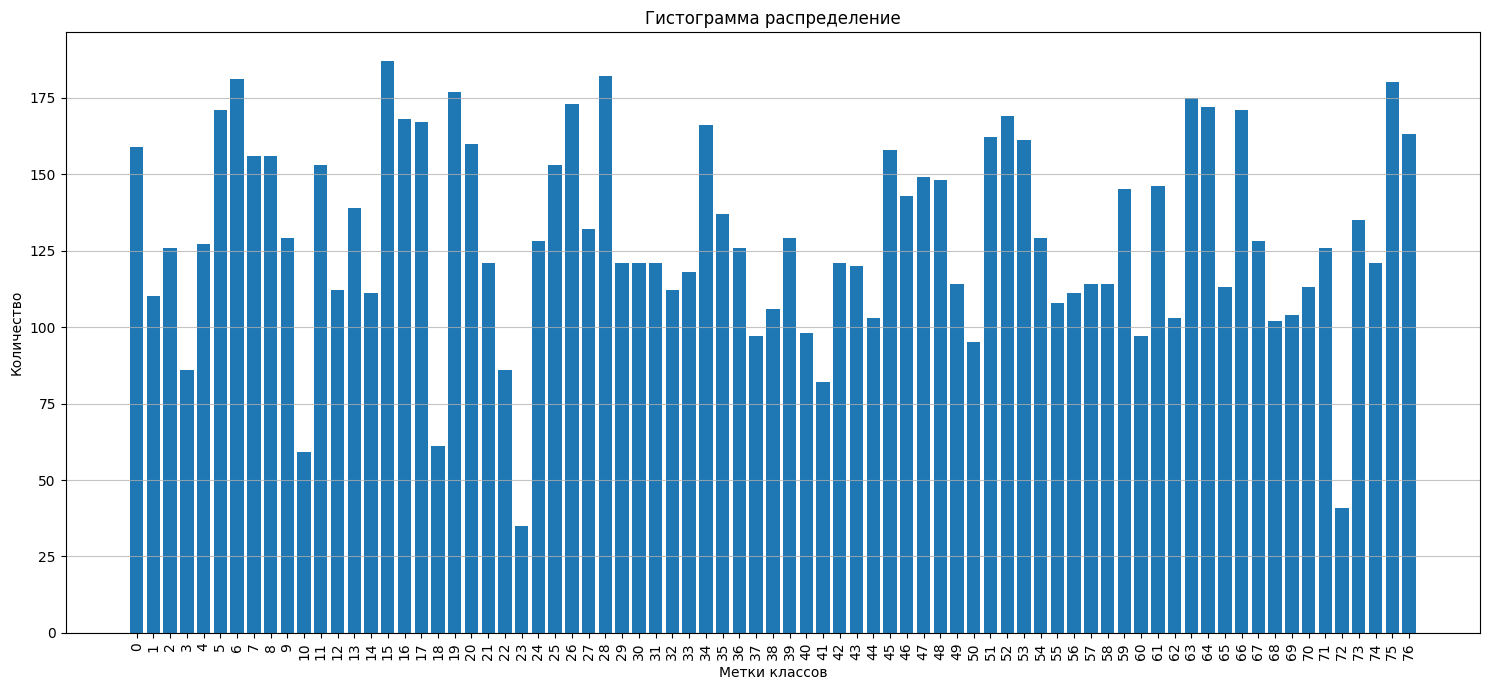

In [9]:
plt.figure(figsize=(15, 7))

num_unique_labels = len(df_train['label'].unique())
plt.hist(df_train['label'], bins=range(num_unique_labels + 1), align='left', rwidth=0.8)
plt.xlabel("Метки классов")
plt.ylabel("Количество")
plt.title("Гистограмма распределение")
plt.xticks(range(num_unique_labels), rotation=90)
plt.grid(axis='y', alpha=0.75)
plt.tight_layout()
plt.show()

Выделим ~относительно редкие классы

In [10]:
rare_labels = df_train['label'].value_counts()
rare_labels = rare_labels[rare_labels < 75].index
rare_labels

Index([18, 10, 72, 23], dtype='int64', name='label')

In [11]:
df_train[df_train['label'].isin(rare_labels)]['label_text'].unique()

array(['contactless_not_working', 'card_acceptance', 'card_swallowed',
       'virtual_card_not_working'], dtype=object)

### Статистика классов

In [12]:
df_train['label'].value_counts().describe()

,count
count,77.000000
mean,129.779221
std,32.974321
min,35.000000
25%,111.000000
50%,127.000000
75%,158.000000
max,187.000000


### Статистика текста

In [13]:
df_train['text'].str.len().describe()

,text
count,9993.000000
mean,59.501351
std,40.873384
min,13.000000
25%,36.000000
50%,47.000000
75%,64.000000
max,433.000000


In [14]:
df_train['text'].isna().sum()

np.int64(0)

## Baseline на лог регрессии

### Обучение - Pipeline

In [15]:
X = df_train['text']
y = df_train['label']

In [17]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

baseline_pipe = Pipeline([
    ('tfidf', TfidfVectorizer(
        max_features=5000,
        ngram_range=(1, 2),
        min_df=2,
        max_df=0.9,
        lowercase=True
    )),
    ('clf', LogisticRegression(
        multi_class='multinomial',
        solver='lbfgs',
        max_iter=1000,
        class_weight='balanced',
        random_state=42
    ))
])


In [18]:
baseline_pipe.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Pipeline(steps=[('tfidf',
                 TfidfVectorizer(max_df=0.9, max_features=5000, min_df=2,
                                 ngram_range=(1, 2))),
                ('clf',
                 LogisticRegression(class_weight='balanced', max_iter=1000,
                                    multi_class='multinomial',
                                    random_state=42))])

In [19]:
train_pred = baseline_pipe.predict(X_train)
val_pred = baseline_pipe.predict(X_val)

### Предсказание - метрики

In [20]:
def report_post_learn(y, y_pred, specific_class=['10', '18', '23', '72']):
  report = classification_report(y, y_pred, output_dict=True)
  df_report = pd.DataFrame(report).T
  return df_report.loc[specific_class + ['macro avg']]

In [21]:
log_reg_model_train_metric = report_post_learn(y_train, train_pred)
log_reg_model_train_metric

,precision,recall,f1-score,support
10,0.818182,0.957447,0.882353,47.0
18,0.960784,1.000000,0.980000,49.0
23,0.964286,0.964286,0.964286,28.0
72,1.000000,1.000000,1.000000,33.0
macro avg,0.935368,0.939399,0.936410,7994.0


In [22]:
log_reg_model_eval_metric = report_post_learn(y_val, val_pred)
log_reg_model_eval_metric

,precision,recall,f1-score,support
10,0.500000,0.750000,0.600000,12.0
18,0.916667,0.916667,0.916667,12.0
23,1.000000,0.571429,0.727273,7.0
72,0.857143,0.750000,0.800000,8.0
macro avg,0.851248,0.841558,0.841685,1999.0


### Рассмотрим важные признаки

In [53]:
name_coef = baseline_pipe['tfidf'].get_feature_names_out()
coef_matrix = baseline_pipe['clf'].coef_
label_to_text_dict = df_train.set_index('label')['label_text'].to_dict()
text_to_label_dict = df_train.set_index('label_text')['label'].to_dict()

count_important = 10
for i, class_name in enumerate(baseline_pipe['clf'].classes_):
    features_important = pd.DataFrame({
        'Признак': name_coef,
        f'Важность_класс_{label_to_text_dict[class_name]}': coef_matrix[i],
        f'abs_важность_класс_{label_to_text_dict[class_name]}': np.abs(coef_matrix[i])
    }).sort_values(f'abs_важность_класс_{label_to_text_dict[class_name]}', ascending=False)

    print(f"\n Топ {count_important} признаков для класса {label_to_text_dict[class_name]}")
    print(features_important.head(count_important))


 Топ 10 признаков для класса activate_my_card
            Признак  Важность_класс_activate_my_card  \
103        activate                         6.039481   
110      activating                         3.868435   
107     activate my                         3.683840   
112      activation                         3.456106   
4092    to activate                         3.432897   
703            card                         3.189390   
111   activating my                         2.499413   
2686        my card                         2.432917   
2815       new card                         2.367975   
109       activated                         2.361062   

      abs_важность_класс_activate_my_card  
103                              6.039481  
110                              3.868435  
107                              3.683840  
112                              3.456106  
4092                             3.432897  
703                              3.189390  
111                         

Для каждого класса модель формирует набор наиболее важных слов.
Эти слова отражают смысл соответствующей категории _label_text_ и помогают модели связывать пользовательский текст с нужной меткой.

Беря за пример - activate с весом - 6.059150, можно сказать, что если в text встретиться данное слово, то с бОльшей вероятностью метка будет - activate_my_card.

Также стоит учитывать что activate, atm, deposite и тд, в некотором смысле специфичны, и поэтому подходят только к своим меткам _label_text_

In [24]:
feature_names = baseline_pipe['tfidf'].get_feature_names_out()

global_importance = np.abs(baseline_pipe['clf'].coef_).sum(axis=0)

global_df = pd.DataFrame({
    'feature': feature_names,
    'overall_feature_importance': global_importance
})

top_global = global_df.sort_values('overall_feature_importance', ascending=False)

top_global.head(20).T


,703,4263,2686,4217,4402,4219,2670,4779,2568,3096,807,409,55,628,4606,1441,2671,1957,3175,3132
feature,card,transfer,my card,top,up,top up,my,why,money,payment,cash,atm,account,can,was,exchange,my account,how,pin,pending
overall_feature_importance,114.955017,90.041304,76.863108,74.723078,69.79307,64.910448,60.605879,58.255396,57.464392,56.219471,56.038872,53.797089,51.638761,49.458271,48.544634,46.570469,45.941285,44.382413,44.281831,43.759896


Стоит отметить, что при анализе важных признаков для отдельных классов можно заметить - многие слова оказываются значимыми сразу для нескольких классов.

Это связано с тем, что такие слова отражают общую специфику банковской тематики, пример, - card, transfer, money, top up и часто встречаются в пользовательских запросах независимо от конкретного класса.

Поэтому модель активно использует их при классификации. Однако подобные признаки хуже помогают разделять классы между собой, поскольку являются слишком общими и не отражают уникальную специфику конкретного класса.

Беря за пример слово - `transfer`. При классах - cancel_transfer, transfer_timing, transfer_fee_charged и подобные слова с приставкой `transfer`

Покажем кодом ниже, что данные слова, что имеют выскокий overall_feature_importance не помогают отделить адекватно классы

In [25]:
def important_features(features_coef, features_name, col_sort='appears_strongly_in_n_classes', top=20):
  absolute_features = np.abs(features_coef)

  global_df = pd.DataFrame({
      'feature': features_name,
      'max_importance': np.max(absolute_features, axis=0),
      'mean_importance': np.mean(absolute_features, axis=0),
      'appears_strongly_in_n_classes': (np.abs(features_coef) > 0.5).sum(axis=0)
  })

  return global_df.sort_values(col_sort, ascending=False).head(top)

In [26]:
important_features(coef_matrix, feature_names)

,feature,max_importance,mean_importance,appears_strongly_in_n_classes
703,card,4.053977,1.492922,69
4263,transfer,5.977106,1.169368,65
4217,top,4.825818,0.970430,63
2686,my card,4.578527,0.998222,62
4402,up,3.973131,0.906404,59
4779,why,2.749086,0.756564,56
2568,money,2.987671,0.746291,53
2670,my,2.049007,0.787089,51
628,can,1.838477,0.642315,49
4219,top up,3.791391,0.842993,48


In [27]:
important_features(coef_matrix, feature_names, 'max_importance')

,feature,max_importance,mean_importance,appears_strongly_in_n_classes
3358,refund,9.247356,0.410368,2
3175,pin,9.123129,0.575089,6
999,contactless,8.503969,0.220882,1
4578,virtual,7.653905,0.477977,6
1241,disposable,7.362381,0.413505,5
3078,passcode,6.893156,0.184443,1
1117,declined,6.869335,0.455211,6
3163,phone,6.670495,0.190845,1
3132,pending,6.643069,0.568310,15
2452,mastercard,6.527548,0.236338,3


Можно увидеть по последней таблице, слова, что явялются спецефичными, имеют выскоую важность для определения целевого класса. Что также демонстрирует колонка _appears_strongly_in_n_classes_, когда для слова приходится малое колчиество классов

### Путаница классов

Рассмотрим, какие классы чаще всего путаются через косинусное сходство

In [28]:
X_train_tfidf = baseline_pipe['tfidf'].transform(df_train['text'])

df_vectors = pd.DataFrame(X_train_tfidf.toarray())

df_vectors['label'] = df_train['label'].values

class_vectors = df_vectors.groupby('label').mean()

In [27]:
sim_matrix = cosine_similarity(class_vectors)

class_names = [label_to_text_dict[i] for i in class_vectors.index]

sim_df = pd.DataFrame(sim_matrix, index=class_names, columns=class_names)

In [28]:
np.fill_diagonal(sim_df.values, 0)

similar_pairs = []

for i in range(len(sim_df)):
    for j in range(i+1, len(sim_df)):
        score = sim_df.iloc[i, j]
        if score > 0.5:
            similar_pairs.append({
                'class1': sim_df.index[i],
                'class2': sim_df.columns[j],
                'similarity': round(score, 4)
            })

similar_pairs_df = pd.DataFrame(similar_pairs)
similar_pairs_df = similar_pairs_df.sort_values('similarity', ascending=False)

similar_pairs_df.head(20)

,class1,class2,similarity
17,card_payment_wrong_exchange_rate,wrong_exchange_rate_for_cash_withdrawal,0.8245
52,top_up_failed,top_up_reverted,0.8032
39,pending_top_up,top_up_failed,0.7719
61,verify_my_identity,why_verify_identity,0.7591
41,pending_top_up,top_up_reverted,0.7421
35,getting_virtual_card,virtual_card_not_working,0.7252
13,card_payment_fee_charged,transfer_fee_charged,0.6936
24,declined_card_payment,reverted_card_payment?,0.6912
19,cash_withdrawal_charge,transfer_fee_charged,0.6848
53,top_up_failed,topping_up_by_card,0.6811


Как видно, между собой метки имеют высокую схожесть, как раз из-за "вредных" слов. Рассмотрми матрицу невязок, чтобы убедиться

In [29]:
cm = confusion_matrix(y_val, val_pred)

error = []

for i in range(cm.shape[0]):
  for j in range(cm.shape[1]):
    if i != j and cm[i][j] > 0:
      true_class = baseline_pipe['clf'].classes_[i]
      pred_class = baseline_pipe['clf'].classes_[j]

      error.append({
          "true_class": true_class,
          "true_class_text": label_to_text_dict[true_class],

          "pred_class": pred_class,
          "pred_class_text": label_to_text_dict[pred_class],

          "count": cm[i][j]
      })

pd.DataFrame(error).sort_values('count', ascending=False).head(20)

,true_class,true_class_text,pred_class,pred_class_text,count
184,64,transfer_fee_charged,34,extra_charge_on_statement,6
88,28,direct_debit_payment_not_recognised,16,card_payment_not_recognised,4
202,68,unable_to_verify_identity,74,why_verify_identity,4
223,76,wrong_exchange_rate_for_cash_withdrawal,75,wrong_amount_of_cash_received,4
141,49,pin_blocked,38,get_physical_card,4
195,66,transfer_not_received_by_recipient,48,pending_transfer,4
96,32,exchange_rate,17,card_payment_wrong_exchange_rate,4
22,7,beneficiary_not_allowed,35,failed_transfer,3
97,33,exchange_via_app,31,exchange_charge,3
134,47,pending_top_up,59,top_up_failed,3


Ошибки как появляются как раз в классах, что имеют высокое значение схожести

### Итого

Анализ confusion matrix показал, что модель чаще всего ошибается между семантически близкими классами

Дополнительный анализ TF-IDF представлений классов подтвердил, что такие классы обладают схожей банковской лексикой

Это демонстрирует ограничение TF-IDF подхода, который опирается преимущественно на лексику и плохо учитывает контекст

## Transformer fine tuning

### Обучение

In [29]:
import torch
import torch.nn.functional as F
import evaluate
import os

from datasets import Dataset

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer
)

In [30]:

dataset = df
dataset = dataset.remove_columns('label_text')
dataset

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 9993
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 3076
    })
})

In [32]:
MODEL_NAME = "distilbert-base-uncased"
MODEL_PATH = "./final_banking77_model"
IS_TRAIN = True

if os.path.exists(MODEL_PATH) and os.path.isdir(MODEL_PATH):
  print('Уже есть модель, закачиваю')
  model = AutoModelForSequenceClassification.from_pretrained(MODEL_PATH, output_attentions=True)
  tokenizer = AutoTokenizer.from_pretrained(MODEL_PATH)
  IS_TRAIN = False

else:
  model = AutoModelForSequenceClassification.from_pretrained(
      MODEL_NAME,
      num_labels=77
  )
  tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)


def tokenize_function(example):
  return tokenizer(
      example['text'],
      padding='max_length',
      max_length=64,
      return_token_type_ids=False,
      truncation=True
  )

Уже есть модель, закачиваю


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

In [33]:
train_dataset = dataset['train'].map(tokenize_function)
test_dataset = dataset['test'].map(tokenize_function)

Map:   0%|          | 0/9993 [00:00<?, ? examples/s]

Map:   0%|          | 0/3076 [00:00<?, ? examples/s]

In [ ]:
train_dataset[0]

{'text': 'I am still waiting on my card?',
 'label': 11,
 'input_ids': [101,
  1045,
  2572,
  2145,
  3403,
  2006,
  2026,
  4003,
  1029,
  102,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0],
 'attention_mask': [1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0]}

In [ ]:
train_dataset.column_names

['text', 'label', 'input_ids', 'attention_mask']

In [34]:
train_dataset.set_format(
    type='torch',
    columns=train_dataset.remove_columns('text').column_names
)
test_dataset.set_format(
    type='torch',
    columns=test_dataset.remove_columns('text').column_names
)
test_dataset[0]

{'label': tensor(11),
 'input_ids': tensor([  101,  2129,  2079,  1045, 12453,  2026,  4003,  1029,   102,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0]),
 'attention_mask': tensor([1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])}

In [ ]:
def compute_metrics(eval_pred):
  logits, labels = eval_pred
  preds = np.argmax(logits, axis=-1)

  metric_acc = evaluate.load('accuracy')
  metric_f1 = evaluate.load('f1')

  acc = metric_acc.compute(
      predictions=preds,
      references=labels,
    )

  f1 = metric_f1.compute(
      predictions=preds,
      references=labels,
      average='macro'
    )

  return {
      'acc': acc['accuracy'],
      'f1': f1['f1']
  }

In [ ]:
os.environ['TENSORBOARD_LOGGING_DIR'] = './log'

args_trainer = TrainingArguments(
    output_dir='./results',

    logging_steps=50,

    eval_strategy='epoch',
    save_strategy='epoch',

    learning_rate=1e-5,

    weight_decay=1e-4,

    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,

    num_train_epochs=3,

    load_best_model_at_end=True,

    metric_for_best_model='eval_f1',

)

In [ ]:
trainer = Trainer(
    model=model,
    args=args_trainer,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics
)

In [ ]:
if IS_TRAIN:
  train_model_result = trainer.train()

Epoch,Training Loss,Validation Loss,Acc,F1
1,0.046849,0.337780,0.914499,0.914758
2,0.053578,0.335955,0.921326,0.921642
3,0.031140,0.336859,0.922302,0.922543


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


In [ ]:
if IS_TRAIN:
  eval_model_result = trainer.evaluate()
  eval_model_result

In [ ]:
if IS_TRAIN:
  trainer.save_model("./final_banking77_model")
  tokenizer.save_pretrained("./final_banking77_model")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('./final_banking77_model/tokenizer_config.json',
 './final_banking77_model/tokenizer.json')

### Сравнение

In [ ]:
pd.DataFrame({
    'model': ['log_reg', 'DistilBERT'],
    'f1_eval': [log_reg_model_eval_metric.loc['macro avg', 'f1-score'], eval_model_result['eval_f1']]
})


,model,f1_eval
0,log_reg,0.841685
1,DistilBERT,0.922543


Соответсвенно, модель что использует механизм вниманимя и учитывает контекстные зависимости дала лучший результат, чем там модель, что учитывает теги слов с классом

### Анализ

Далее сделаем предсказание baseline модели и bert модели на test выборки

In [35]:
X_test = df_test['text']
y_test = df_test['label']

log_reg_test_pred = baseline_pipe.predict(X_test)

In [36]:
def predict_distilbert(texts, batch_size=32):
  model.eval()

  all_preds = []
  all_probs = []

  for i in range(0, len(texts), batch_size):
    batch_texts = texts[i:i+batch_size]

    inputs = tokenizer(
        batch_texts,
        padding=True,
        truncation=True,
        max_length=64,
        return_tensors='pt'
    )

    with torch.no_grad():
      outputs = model(**inputs)

    probs = F.softmax(outputs.logits, dim=-1)
    preds = torch.argmax(probs, dim=-1)

    all_preds.extend(preds.cpu().numpy())
    all_probs.extend(probs.cpu().numpy())

  return np.array(all_preds), np.array(all_probs)

bert_test_pred, bert_test_probs = predict_distilbert(X_test.tolist())

In [46]:
comprision_test_df = pd.DataFrame({
    'text': X_test.values,
    'true_label': y_test.values,
    'log_reg_pred': log_reg_test_pred,
    'bert_pred': bert_test_pred
})

In [47]:
comprision_test_df['true_label_text'] = comprision_test_df['true_label'].map(label_to_text_dict)
comprision_test_df['log_reg_pred_text'] = comprision_test_df['log_reg_pred'].map(label_to_text_dict)
comprision_test_df['bert_pred_text'] = comprision_test_df['bert_pred'].map(label_to_text_dict)

In [51]:
fixed_errors = comprision_test_df[
    (comprision_test_df['log_reg_pred'] != comprision_test_df['true_label']) &
    (comprision_test_df['bert_pred'] == comprision_test_df['true_label'])
]
fixed_errors.shape

(258, 7)

In [50]:
fixed_errors[
    [
        'text',
        'true_label_text',
        'log_reg_pred_text',
        'bert_pred_text'
    ]
].sample(20, random_state=42)

,text,true_label_text,log_reg_pred_text,bert_pred_text
987,areas card is accpeted,card_acceptance,card_about_to_expire,card_acceptance
659,Why hasn't my top-up been completed?,pending_top_up,top_up_reverted,pending_top_up
197,What is the €1 fee for?,extra_charge_on_statement,card_payment_fee_charged,extra_charge_on_statement
1053,The balance on my account wasn't updated after...,balance_not_updated_after_cheque_or_cash_deposit,balance_not_updated_after_bank_transfer,balance_not_updated_after_cheque_or_cash_deposit
1706,I want this amount reversed out of my account.,request_refund,terminate_account,request_refund
1384,Can you explain the virtual cards limit?,disposable_card_limits,getting_virtual_card,disposable_card_limits
2538,Is there a trick to get the disposable virtual...,virtual_card_not_working,get_disposable_virtual_card,virtual_card_not_working
2806,I just topped off my card will I be charged fo...,top_up_by_card_charge,top_up_by_bank_transfer_charge,top_up_by_card_charge
1575,What are some reasons that would cause ATM mac...,declined_cash_withdrawal,atm_support,declined_cash_withdrawal
2577,I feel like too much money was taken during my...,wrong_exchange_rate_for_cash_withdrawal,exchange_charge,wrong_exchange_rate_for_cash_withdrawal


Далее рассмотрим весовые коэффициенты и веса внимания при предсказании классов для нескольких строк

In [132]:
def show_text(num_sample):
  print(fixed_errors.loc[num_sample, 'text'])
  print(fixed_errors.loc[num_sample, ['true_label_text', 'log_reg_pred_text', 'bert_pred_text']])

In [122]:
def log_reg_weight_tfidf(num_sample):
  tfidf_vector = baseline_pipe['tfidf'].transform([fixed_errors.loc[num_sample, 'text']])
  feature_names = baseline_pipe['tfidf'].get_feature_names_out()

  pred_class = fixed_errors.loc[num_sample, 'log_reg_pred']
  class_coefs = baseline_pipe['clf'].coef_[pred_class]

  contributions = tfidf_vector.toarray()[0] * class_coefs

  contrib_df = pd.DataFrame({
    'token': feature_names,
    'tfidf': tfidf_vector.toarray()[0],
    'coef': class_coefs,
    'contribution': contributions
  })
  contrib_df = contrib_df[
      contrib_df['tfidf'] > 0
  ]
  print(contrib_df.sort_values(
      'contribution',
      ascending=False
  ).head(15))

In [118]:
def bert_attention(num_sample):

  inputs = tokenizer(
    fixed_errors.loc[num_sample, 'text'],
    return_tensors='pt',
    truncation=True,
    max_length=64
  )

  with torch.no_grad():
      outputs = model(**inputs)

  last_attention = outputs.attentions[-1]
  mean_attention = last_attention.mean(dim=1)[0]

  tokens = tokenizer.convert_ids_to_tokens(
    inputs['input_ids'][0]
  )

  plt.figure(figsize=(8, 6))

  plt.imshow(mean_attention.cpu(), cmap='viridis')

  plt.xticks(range(len(tokens)), tokens, rotation=90)
  plt.yticks(range(len(tokens)), tokens)

  plt.colorbar()

  plt.title('Attention Heatmap')

  plt.tight_layout()
  plt.show()

In [136]:
def show_all(num_sample):
  print("------###------")
  show_text(num_sample)
  print()
  log_reg_weight_tfidf(num_sample)
  print()
  bert_attention(num_sample)
  print("------###------")

------###------
What are some reasons that would cause ATM machines to decline my card? It has happened to me multiple times!
true_label_text      declined_cash_withdrawal
log_reg_pred_text                 atm_support
bert_pred_text       declined_cash_withdrawal
Name: 1575, dtype: object

             token     tfidf      coef  contribution
409            atm  0.126406  5.177354      0.654447
423   atm machines  0.262203  0.613687      0.160911
1116    decline my  0.256497  0.593312      0.152182
2382      machines  0.225797  0.502519      0.113467
1114       decline  0.222110  0.480097      0.106635
2473            me  0.102731  0.746489      0.076688
4141         to me  0.184426  0.349429      0.064444
4677          what  0.089938  0.636533      0.057249
342            are  0.123371  0.426842      0.052660
703           card  0.073444  0.613540      0.045061
3802          that  0.106649  0.422242      0.045032
4679      what are  0.169391  0.026626      0.004510
2686       my card  

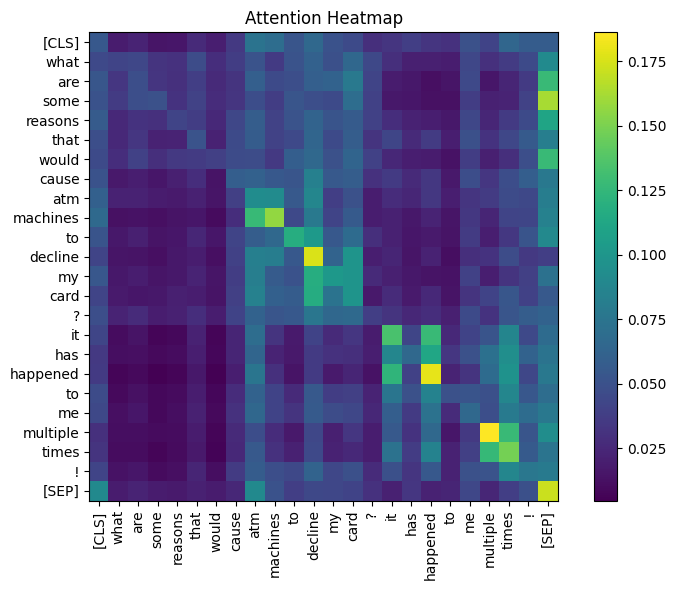

------###------
------###------
Can I unblock my card using the app?
true_label_text       pin_blocked
log_reg_pred_text    card_linking
bert_pred_text        pin_blocked
Name: 537, dtype: object

           token     tfidf      coef  contribution
3858     the app  0.289199  3.021715      0.873877
307          app  0.265837  3.066885      0.815292
703         card  0.153854  3.637485      0.559641
2686     my card  0.198364  1.168822      0.231852
3852         the  0.148383  0.905685      0.134388
628          can  0.170811  0.678905      0.115965
2670          my  0.110065  0.136814      0.015058
4535   using the  0.469037 -0.038284     -0.017957
4382  unblock my  0.455182 -0.055635     -0.025324
4380     unblock  0.438703 -0.069775     -0.030610
4524       using  0.315785 -0.283768     -0.089610



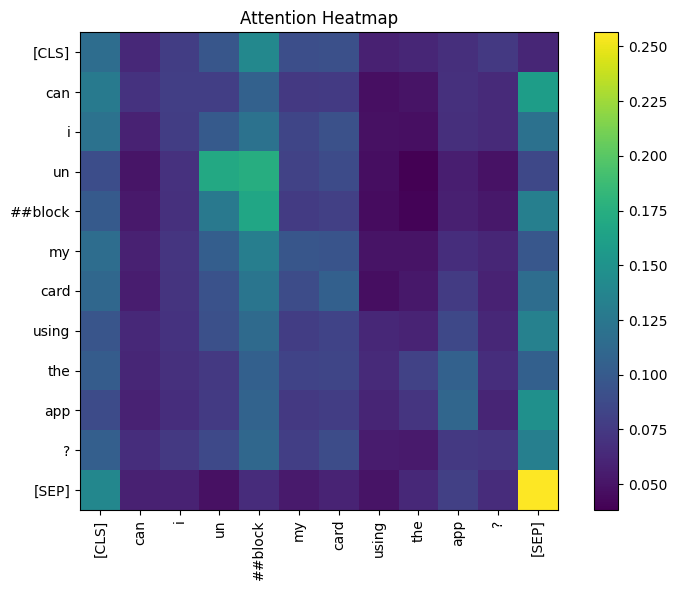

------###------
------###------
How do I get my PIN unlocked?
true_label_text            pin_blocked
log_reg_pred_text    get_physical_card
bert_pred_text             pin_blocked
Name: 519, dtype: object

       token     tfidf      coef  contribution
3175     pin  0.361609  9.123129      3.299007
2750  my pin  0.396467  3.835644      1.520706
1751  get my  0.439528  1.136830      0.499669
1733     get  0.290667  1.258551      0.365820
1269  do get  0.443615  0.679926      0.301625
1962  how do  0.329345  0.761050      0.250648
1957     how  0.237062  0.641090      0.151978
1251      do  0.232195  0.616854      0.143230
2670      my  0.137859  0.834518      0.115046



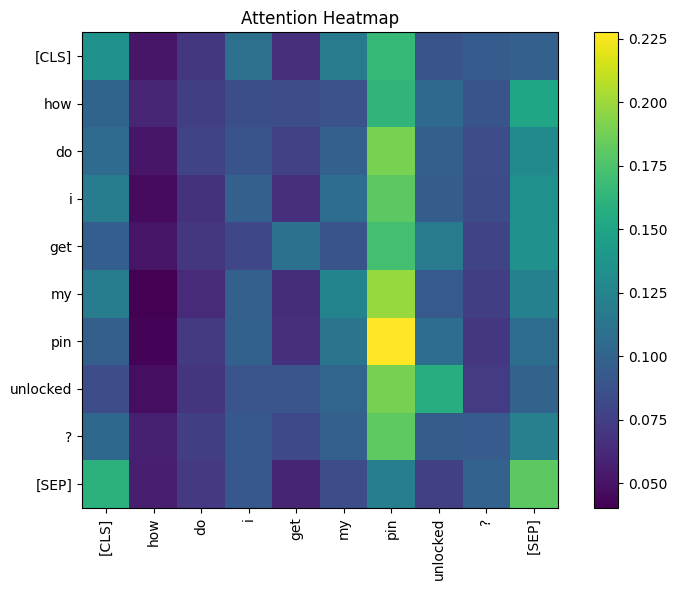

------###------


In [137]:
text_sample = [1575, 537, 519]
for s in text_sample:
  show_all(s)

## Итого

### Итоги анализа

Как говорилось ранее, tf-idf + logreg преймущественно опираются на отдельные лексические признаки, что еще раз видно при превом запросе и вкладе слова - atm = 0.654447, из за чего и выдает - atm_support как целевой класс. Модель baseline не учитывает общий контекст запроса и связи между decline, card declined и тд

В случае использования BERT наблюдается другое поведение - модель учитывает взаимодействия между токенами и строит контекстные зависимости, что позволяет корректно интерпретировать смысл запроса как проблему отказа транзакции

Аналогичная ситуация наблюдается и во втором примере, где transformer корректно определяет класс благодаря учёту контекста всей фразы, тогда как baseline опирается на поверхностные совпадения слов

С третьим запросом интереснее ситуация. Baseline выделила слово `pin` как важное, но при этом допустила ошибку. Это можно объяснить тем, что произошла лексический паттерный конфилкит, то есть слово `pin` baseline запомнила под другим контекстом для другого класса

Трансфомер модель, напротив, смогла адекватно установить связь между - PIN unlocked и pin_blocked

Также представлена визуализация взаимодействия внимания токенов. Данная визуализация не является строгим объяснением принятия решений модели, однако может дать интуитивное понимание того, какие токены взаимодействуют сильнее в контексте входного запроса

### Возможные улучшения

На основе анализа ошибок моделей можно выделить несколько для улучшения классификации в реальном времени:

1) многие ошибки возникают из-за высокой семантической схожести пользовательских запросов между разными классами. Это может указывать на необходимость более чёткой формулировки пользовательских сценариев в поддержки, например через уточняющие вопросы или выбор категорий проблемы

2) возможно улучшение структуры входных данных за счёт направляющих подсказок , к примеру, - Что именно произошло с картой? - вместо свободного ввода текста, что снижает долю неоднозначных запросов